**LIBRARIES**

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import heapq
import statistics
import collections

**DATA LOADING**

In [2]:
def load_data(path, is_directed=False):
    graph_type = nx.DiGraph() if is_directed else nx.Graph()
    G = nx.read_edgelist(path, create_using=graph_type, nodetype=int)
    print(f"Nodes: {G.number_of_nodes():,}")
    print(f"Edges: {G.number_of_edges():,}")
    print(f"Density: {nx.density(G):.6f}")
    if is_directed:
        print(f"Weakly Connected Components: {nx.number_weakly_connected_components(G):,}")
    else:
        print(f"Connected Components: {nx.number_connected_components(G):,}")

    return G
G1 = load_data("/content/drive/MyDrive/Explo/Wiki-Vote.txt", is_directed=True)
G2 = load_data("/content/drive/MyDrive/Explo/facebook_combined.txt")

Nodes: 7,115
Edges: 103,689
Density: 0.002049
Weakly Connected Components: 24
Nodes: 4,039
Edges: 88,234
Density: 0.010820
Connected Components: 1


**SEED SELECTION STRATEGIES**

In [3]:
class Seed_Selection:
    def __init__(self, G, k):
        self.Graph = G
        self.seed_size = k
        self.degree_dict = dict(self.Graph.degree())
        self.betweenness_dict = nx.betweenness_centrality(self.Graph)
        self.closeness_dict = nx.closeness_centrality(self.Graph)

    def random_seeds(self):
        return set(random.sample(list(self.Graph.nodes()), self.seed_size))

    def degree_based(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.degree_dict,
            key=self.degree_dict.get
        )
        return set(top_k)

    def betweenness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.betweenness_dict,
            key=self.betweenness_dict.get
        )
        return set(top_k)

    def closeness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.closeness_dict,
            key=self.closeness_dict.get
        )
        return set(top_k)


**MONTE CARLO SIMULATIONS**

In [4]:
class Experiment:
    def __init__(self, G, model_class, seed_set, runs, random_seed=None, param_func=None):
        self.G = G
        self.model_class = model_class
        self.seed_set = seed_set
        self.runs = runs
        self.random_seed = random_seed
        self.param_func = param_func
        self.results_per_run = []
        self.aggregated_results = None

    def compute_metrics(self, final_active, history):
        return {
            "spread_size": len(final_active),
            "diffusion_time": len(history),
            "activations_over_time": [len(step) for step in history]
        }

    def aggregate_results(self):
        spreads = [r["spread_size"] for r in self.results_per_run]
        times = [r["diffusion_time"] for r in self.results_per_run]

        return {
            "mean_spread": sum(spreads) / self.runs,
            "std_spread": statistics.stdev(spreads) if self.runs > 1 else 0,
            "mean_diffusion_time": sum(times) / self.runs,
            "raw_results": self.results_per_run
        }

    def run(self):
        self.results_per_run = []
        for i in range(self.runs):
            if self.random_seed is not None:
                random.seed(self.random_seed + i)

            current_params = self.param_func(self.G) if self.param_func else {}

            model_instance = self.model_class(self.G, self.seed_set, **current_params)
            final_active, history = model_instance.run()

            self.results_per_run.append(self.compute_metrics(final_active, history))

        self.aggregated_results = self.aggregate_results()
        return self.aggregated_results

**PLOTTING FUNCTIONS**

In [5]:
# 1. Diffusion Curve
def plot_diffusion_curves(multi_results):
    plt.figure(figsize=(10, 6))

    for graph_name, results in multi_results.items():
        first_run = results["raw_results"][0]
        curve = first_run["activations_over_time"]
        plt.plot(range(len(curve)), curve, marker='o', label=graph_name)

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel("New Activations", fontsize=12)
    plt.title("Diffusion Curves Across Datasets", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


# 2. Average Final Spread
def plot_final_spreads(multi_results):
    plt.figure(figsize=(10, 6))

    names = list(multi_results.keys())
    means = [results["mean_spread"] for results in multi_results.values()]

    plt.bar(names, means, color='skyblue', edgecolor='black')
    plt.ylabel("Active Nodes", fontsize=12)
    plt.title("Average Final Spread Across Datasets", fontsize=14)
    plt.show()


# 3. Spread Distribution
def plot_spread_distributions(multi_results):
    plt.figure(figsize=(10, 6))

    for graph_name, results in multi_results.items():
        spreads = [r["spread_size"] for r in results["raw_results"]]
        plt.hist(spreads, bins=10, alpha=0.6, label=graph_name, edgecolor='black')

    plt.xlabel("Final Spread", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Spread Distribution Across Runs", fontsize=14)
    plt.legend()
    plt.show()


# 4. Diffusion Time
def plot_diffusion_times(multi_results):
    plt.figure(figsize=(10, 6))

    names = list(multi_results.keys())
    times = [results["mean_diffusion_time"] for results in multi_results.values()]

    plt.bar(names, times, color='lightgreen', edgecolor='black')
    plt.ylabel("Time Steps", fontsize=12)
    plt.title("Average Diffusion Time Across Datasets", fontsize=14)
    plt.show()


# 5. Variance Plot
def plot_variances(multi_results):
    plt.figure(figsize=(10, 6))

    data_to_plot = []
    labels = []

    for graph_name, results in multi_results.items():
        spreads = [r["spread_size"] for r in results["raw_results"]]
        data_to_plot.append(spreads)
        labels.append(graph_name)

    plt.boxplot(data_to_plot, tick_labels=labels, patch_artist=True)
    plt.ylabel("Final Spread", fontsize=12)
    plt.title("Spread Variability Across Datasets", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


# 6. Compare Models (Grouped Bar Chart)
def compare_models_across_graphs(graphs_dict, models, seeds):
    model_names = [m.__name__ for m in models]
    x = np.arange(len(model_names))
    num_graphs = len(graphs_dict)
    width = 0.8 / num_graphs
    plt.figure(figsize=(12, 6))
    for i, (graph_name, G) in enumerate(graphs_dict.items()):
        means = []
        print(f"Running models on {graph_name}...")

        for model_class in models:
            exp = Experiment(G, model_class, seeds, 42, 20)
            results = exp.run()
            means.append(results["mean_spread"])
        offset = (i - num_graphs / 2 + 0.5) * width
        plt.bar(x + offset, means, width, label=graph_name)

    plt.ylabel("Mean Spread", fontsize=12)
    plt.title("Model Comparison Across Datasets", fontsize=14)
    plt.xticks(x, model_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
#Compare seed strategies
def compare_seed_strategies_across_graphs(graphs_dict, model_class, k, runs=20, param_generator=None):

    means_random = []
    means_hd = []
    graph_names = list(graphs_dict.keys())
    all_results = {}
    for graph_name, G in graphs_dict.items():
        print(f"Testing strategies on {graph_name}...")
        seed_selector = Seed_Selection(G, k)

        #Strategy 1: Random Seeds
        seeds_random = seed_selector.random_seeds()
        exp_random = Experiment(
            G,
            model_class,
            seeds_random,
            runs,
            random_seed=42,
            param_func=param_generator
        )
        results_random = exp_random.run()
        means_random.append(results_random["mean_spread"])

        #Strategy 2: High Degree Seeds
        seeds_hd = seed_selector.degree_based()
        exp_hd = Experiment(
            G,
            model_class,
            seeds_hd,
            runs,
            random_seed=42,
            param_func=param_generator
        )
        results_hd = exp_hd.run()
        means_hd.append(results_hd["mean_spread"])
        all_results[graph_name] = {
            "random": results_random,
            "high_degree": results_hd
        }
    x = np.arange(len(graph_names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, means_random, width, label='Random Seeds', color='skyblue', edgecolor='black')
    ax.bar(x + width/2, means_hd, width, label='High Degree Seeds', color='salmon', edgecolor='black')
    ax.set_ylabel("Mean Final Spread", fontsize=12)
    ax.set_title(f"Strategy Comparison: {model_class.__name__} (k={k}) Across Datasets", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(graph_names)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()
    return all_results

In [7]:
# Analysis Based On seed sizes
def analyze_seed_sizes_across_graphs(graphs_dict, model_class, seed_strategy="Random", seed_sizes=[5, 10, 20, 50], runs=20, param_generator=None):
    all_results = {}
    plt.figure(figsize=(10, 6))

    for graph_name, G in graphs_dict.items():
        print(f"\n--- Running seed size analysis on {graph_name} ---")
        mean_spreads = []
        for k in seed_sizes:
            seed_selector = Seed_Selection(G, k)
            if seed_strategy == "Random":
                seeds = seed_selector.random_seeds()
            elif seed_strategy == "DegreeBased":
                seeds = seed_selector.degree_based()
            else:
                raise ValueError("Strategy must be 'Random' or 'DegreeBased'")
            exp = Experiment(
                G,
                model_class,
                seeds,
                runs,
                random_seed=42,
                param_func=param_generator
            )
            results = exp.run()
            mean_spread_val = results["mean_spread"]
            mean_spreads.append(mean_spread_val)
            print(f"  k={k} | Mean Spread: {mean_spread_val:.2f}")
        all_results[graph_name] = dict(zip(seed_sizes, mean_spreads))
        plt.plot(seed_sizes, mean_spreads, marker='o', linestyle='-', linewidth=2, label=graph_name)

    plt.xlabel("Number of Seed Nodes ($k$)", fontsize=12)
    plt.ylabel("Mean Final Spread", fontsize=12)
    plt.title(f"Influence Spread vs Seed Size ({seed_strategy}) - {model_class.__name__}", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return all_results

**THRESHOLD MODELS**

*Linear Threshold*

In [20]:
class LinearThreshold:
    def __init__(self, G, A0, thresholds, weights):
        self.graph = G
        self.active_nodes = set(A0)
        self.newly_active = list(A0)
        self.history = [set(A0)]
        self.theta = thresholds
        self.weights = weights
        self.influence_sum = {node: 0.0 for node in G.nodes()}


    def run(self):
        while self.newly_active:
            candidates = set()
            for u in self.newly_active:
                for v in self.graph.neighbors(u):
                    if v not in self.active_nodes:
                        self.influence_sum[v] += self.weights.get((u, v), 0)
                        candidates.add(v)

            next_step_active = []
            for v in candidates:
                if self.influence_sum[v] >= self.theta[v]:
                    next_step_active.append(v)
                    self.active_nodes.add(v)

            if not next_step_active:
                break

            self.history.append(set(next_step_active))
            self.newly_active = next_step_active

        return self.active_nodes, self.history

In [22]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()

weights1 = {(u, v): 1.0 / G1.degree(v) for u, v in G1.edges()}
weights2 = {(u, v): 1.0 / G2.degree(v) for u, v in G2.edges()}

#Param Function
def get_lt_params(low_val, high_val, weights):
    def param_func(G):
        return {
            "thresholds": {n: random.uniform(low_val, high_val) for n in G.nodes()},
            "weights": weights
        }
    return param_func

lt_params1 = get_lt_params(low_val=0.01, high_val=0.05, weights=weights1)
lt_params2 = get_lt_params(low_val=0.01, high_val=0.05, weights=weights2)

results_wiki = Experiment(G1, LinearThreshold, seeds1, runs=10, param_func=lt_params1).run()
results_fb = Experiment(G2, LinearThreshold, seeds2, runs=10, param_func=lt_params2).run()

all_results = {
    "Wiki-Vote": results_wiki,
    "Facebook": results_fb,
}


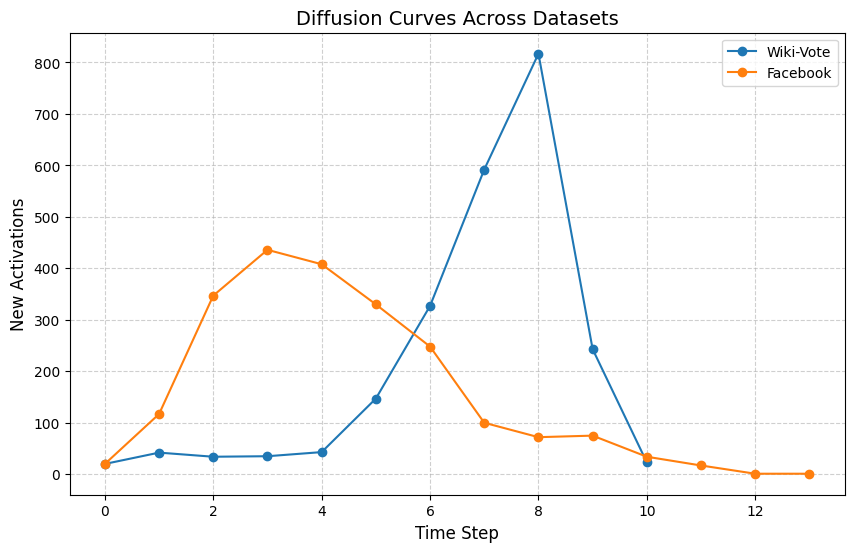

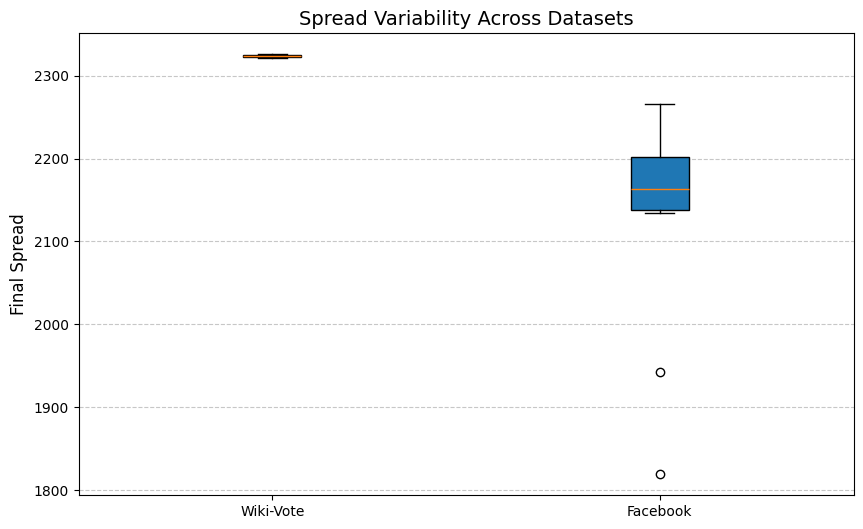

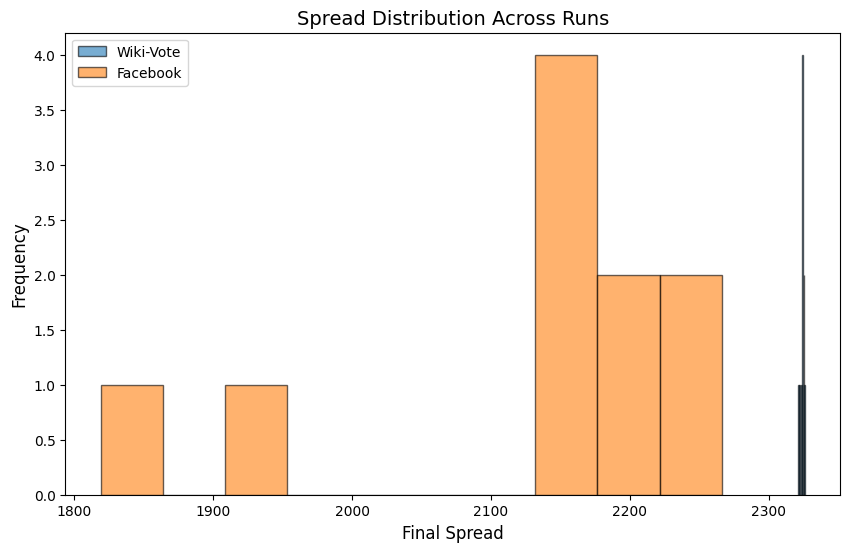

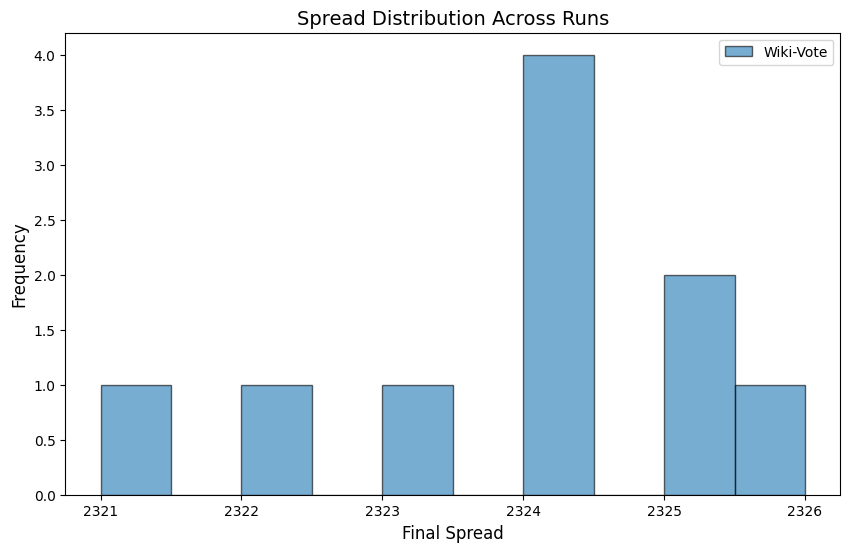

In [27]:
plot_diffusion_curves(all_results)
plot_variances(all_results)
plot_spread_distributions(all_results)
all_resultsk = {
    "Wiki-Vote": results_wiki,
}
plot_spread_distributions(all_resultsk)

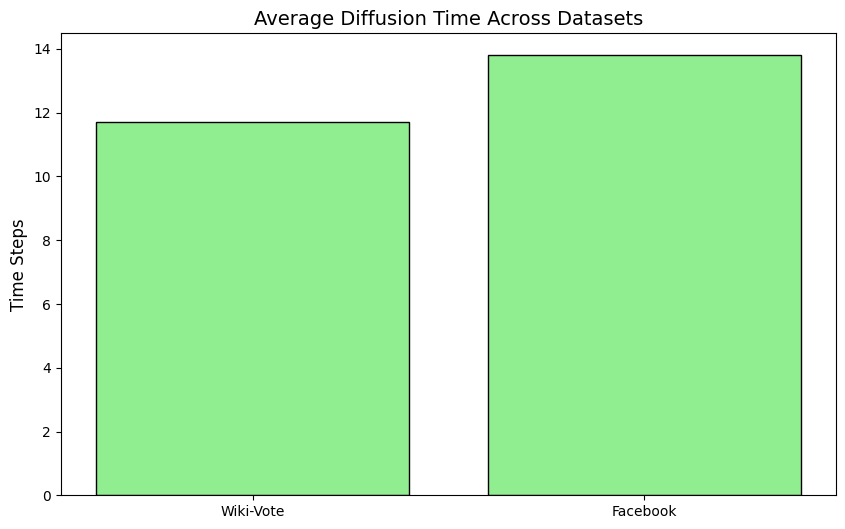

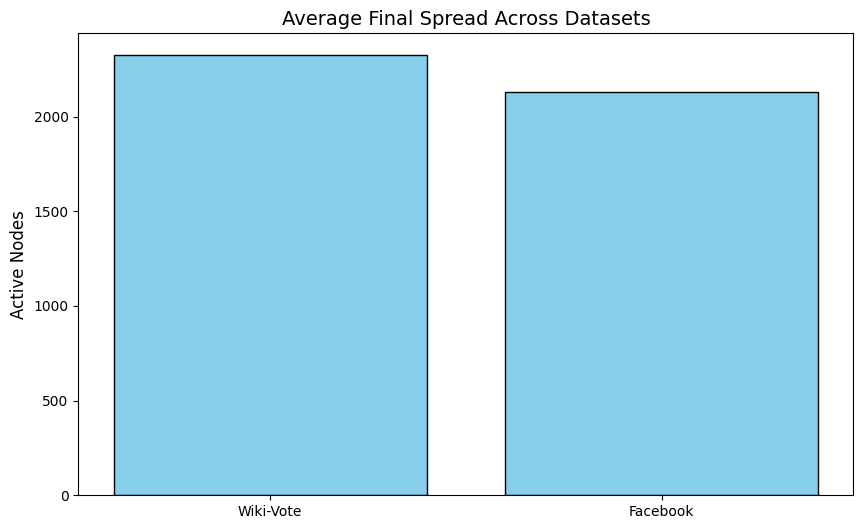

In [24]:
plot_diffusion_times(all_results)
plot_final_spreads(all_results)

Testing strategies on Wiki-Vote...


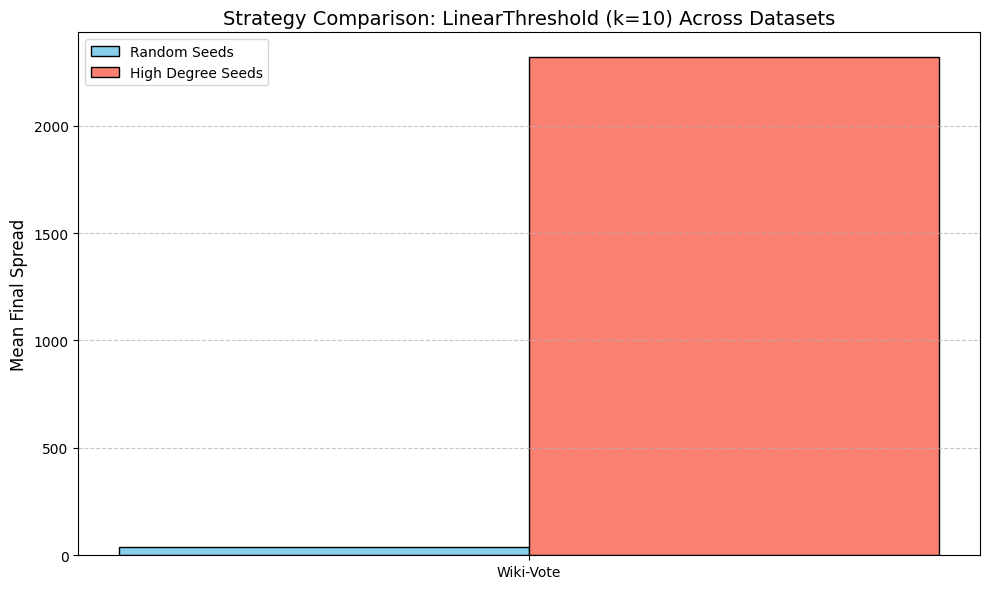

Testing strategies on Facebook...


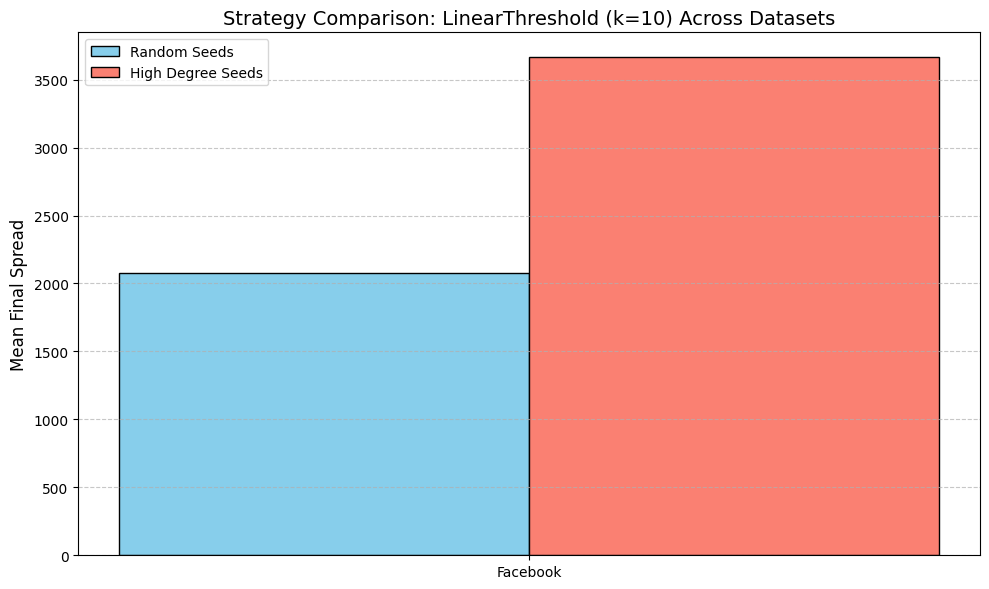

In [25]:
Graph_dict1 = {
    "Wiki-Vote": G1,
    }
Graph_dict2 = {
    "Facebook": G2
    }
strategy_results1 = compare_seed_strategies_across_graphs(Graph_dict1, LinearThreshold, k=10, runs = 5,
    param_generator=lt_params1)
strategy_results2 = compare_seed_strategies_across_graphs(Graph_dict2, LinearThreshold, k=10, runs = 5,
    param_generator=lt_params2)


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 2313.40
  k=10 | Mean Spread: 2318.40
  k=15 | Mean Spread: 2318.40
  k=20 | Mean Spread: 2318.40


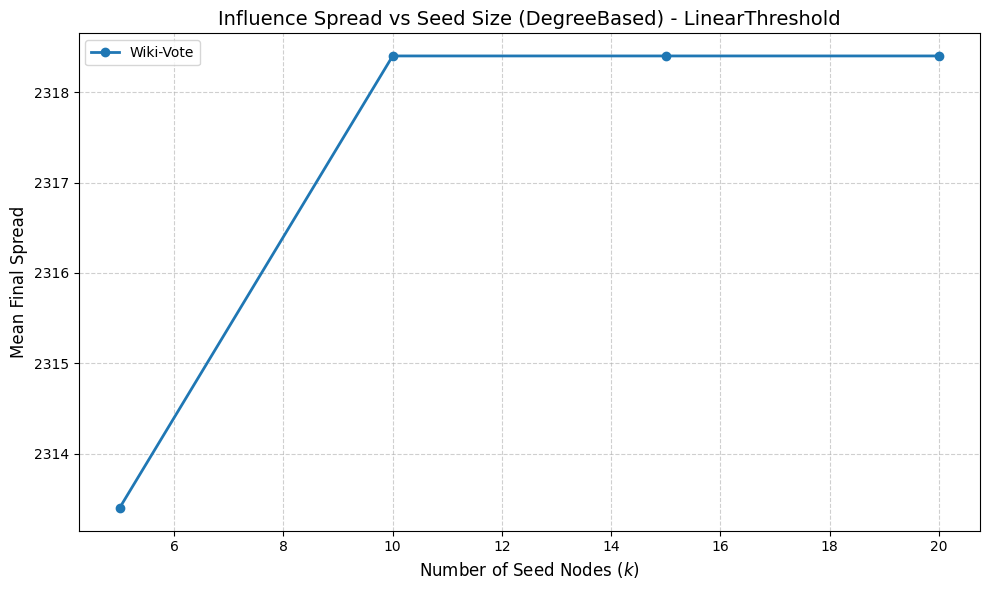


--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 3664.60
  k=10 | Mean Spread: 3664.60
  k=15 | Mean Spread: 3727.00
  k=20 | Mean Spread: 3727.00


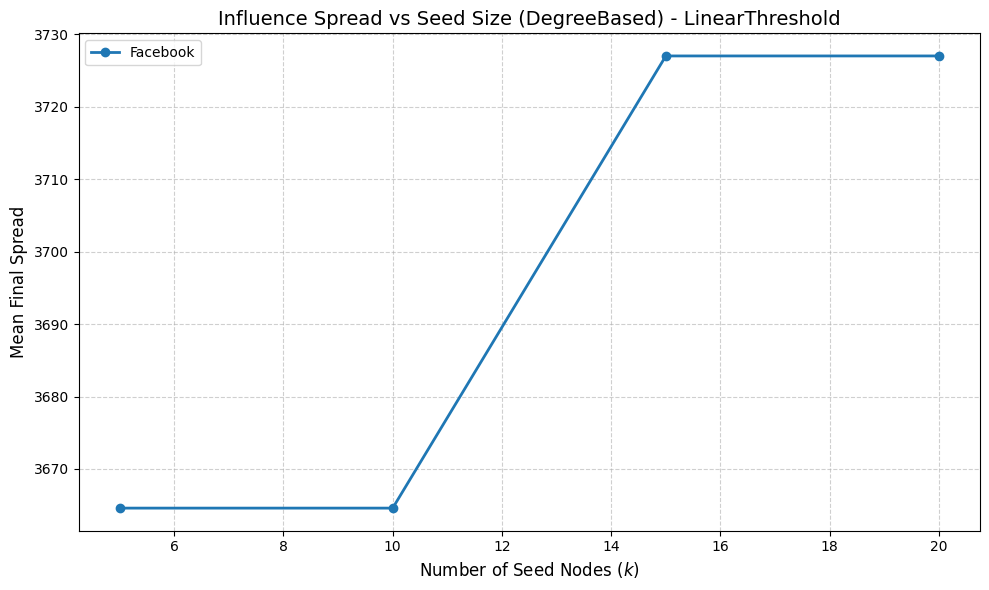

In [26]:
size_results1 = analyze_seed_sizes_across_graphs(
    Graph_dict1,
    LinearThreshold,
    seed_strategy="DegreeBased",
    seed_sizes=[5, 10, 15, 20],
    runs = 5,
    param_generator=lt_params1
)
size_results2 = analyze_seed_sizes_across_graphs(
    Graph_dict2,
    LinearThreshold,
    seed_strategy="DegreeBased",
    seed_sizes=[5, 10, 15, 20],
    runs = 5,
    param_generator=lt_params2
)

*Small Threshold Model*

In [ ]:
class Small_Threshold:
    def __init__(self, G, A0, k):
        self.graph = G
        self.active_nodes = set(A0)
        self.newly_active = list(A0)
        self.history = [set(A0)]
        self.k = k
        self.active_neighbor_count = {node: 0 for node in G.nodes()}

    def run(self):
        while self.newly_active:
            next_newly_active = []
            candidates = set()

            for u in self.newly_active:
                for v in self.graph.neighbors(u):
                    if v not in self.active_nodes:
                        self.active_neighbor_count[v] += 1
                        candidates.add(v)

            for v in candidates:
                if self.active_neighbor_count[v] >= self.k:
                    next_newly_active.append(v)
                    self.active_nodes.add(v)

            if not next_newly_active:
                break

            self.history.append(set(next_newly_active))
            self.newly_active = next_newly_active

        return self.active_nodes, self.history

In [ ]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()

#Param Function
def st_params(graph):
    return {
        "k": 2
    }
results_wiki1 = Experiment(G1, Small_Threshold, seeds1, runs=10, param_func=st_params).run()
results_fb1 = Experiment(G2, Small_Threshold, seeds2, runs=10, param_func=st_params).run()

all_results1 = {
    "Wiki-Vote": results_wiki1,
    "Facebook": results_fb1,
}

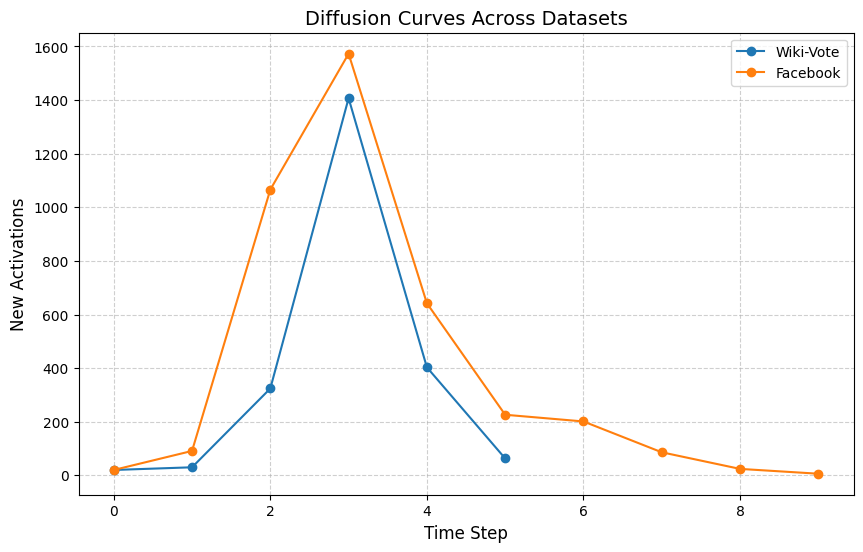

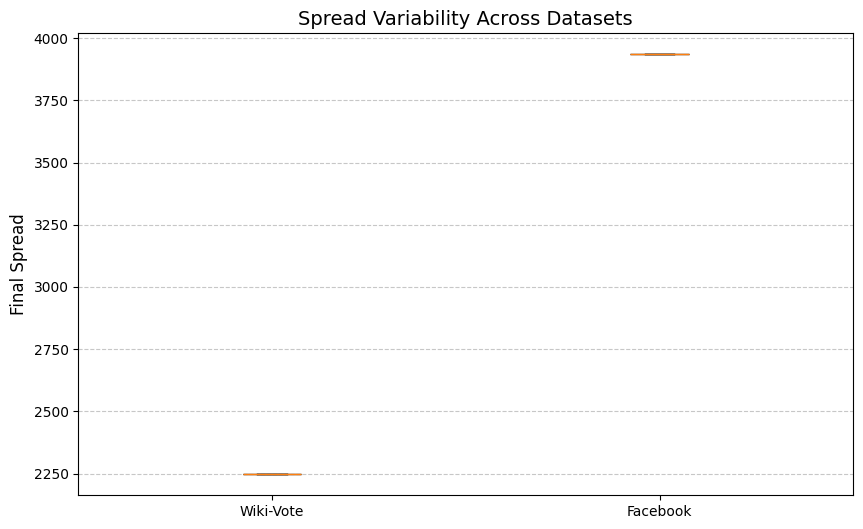

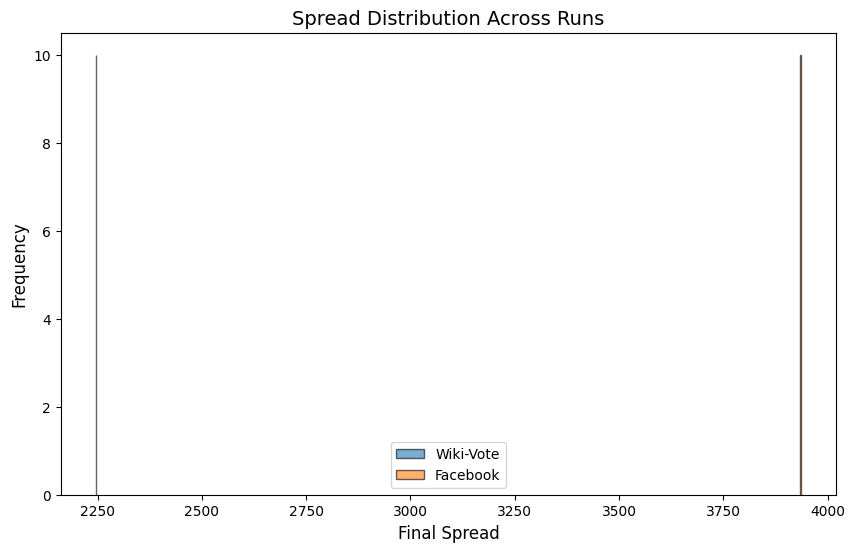

In [ ]:
plot_diffusion_curves(all_results1)
plot_variances(all_results1)
plot_spread_distributions(all_results1)

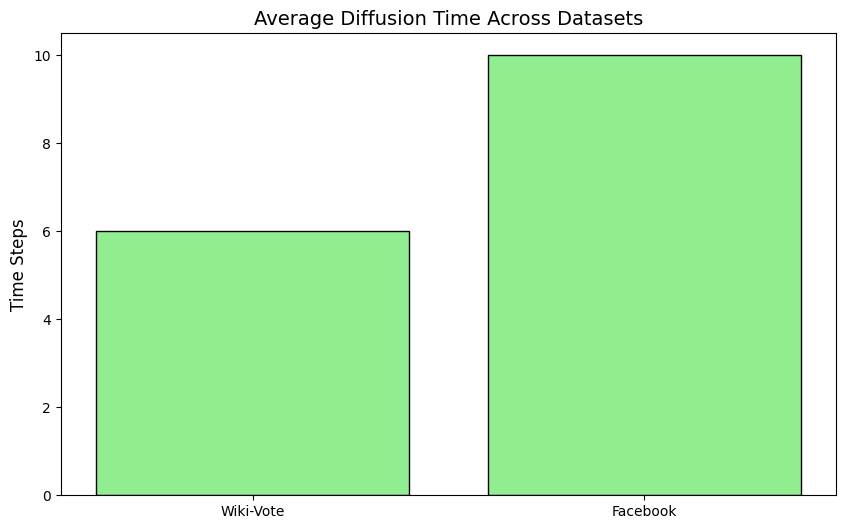

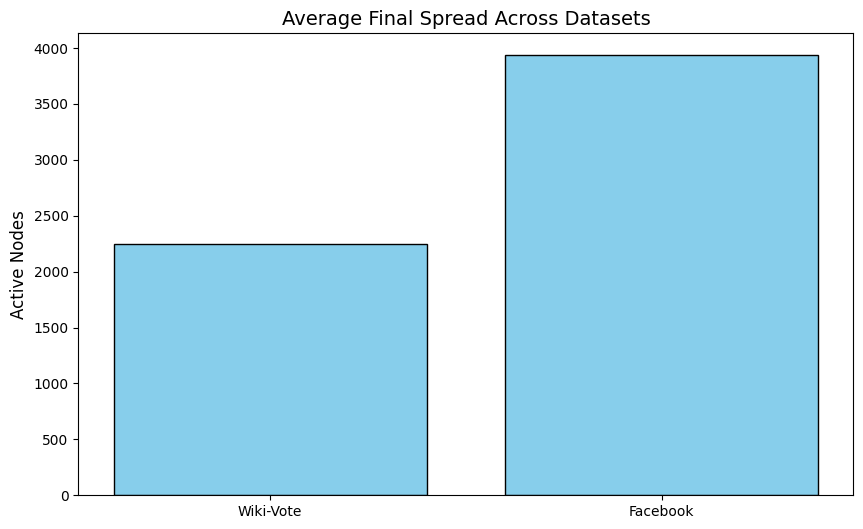

In [ ]:
plot_diffusion_times(all_results1)
plot_final_spreads(all_results1)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


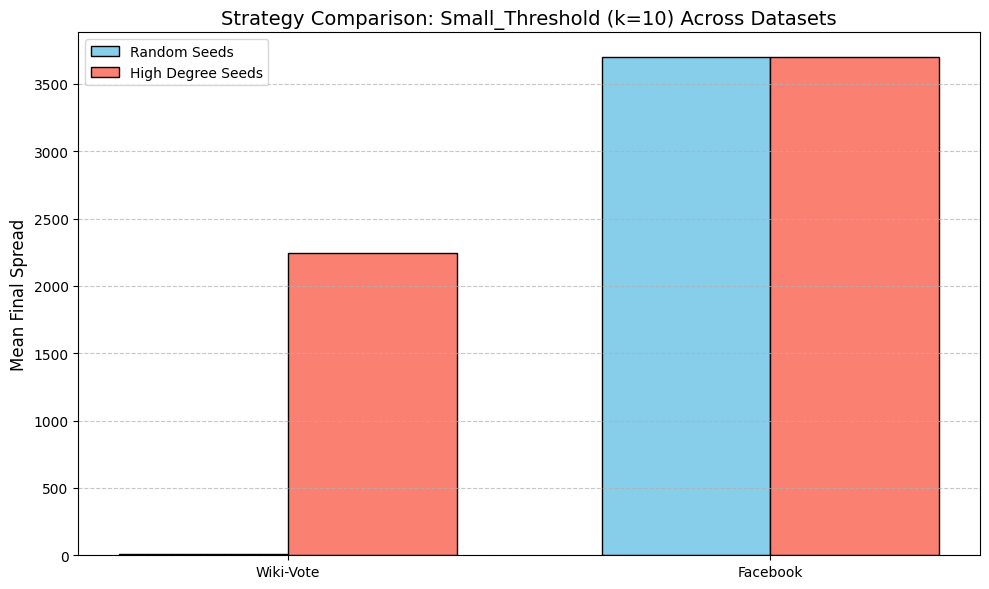

In [ ]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
strategy_results = compare_seed_strategies_across_graphs(Graph_dict, Small_Threshold, k=10, runs = 5,
    param_generator=st_params)


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 2237.00
  k=10 | Mean Spread: 2241.00
  k=15 | Mean Spread: 2241.00
  k=20 | Mean Spread: 2241.00

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 3698.00
  k=10 | Mean Spread: 3698.00
  k=15 | Mean Spread: 3698.00
  k=20 | Mean Spread: 3698.00


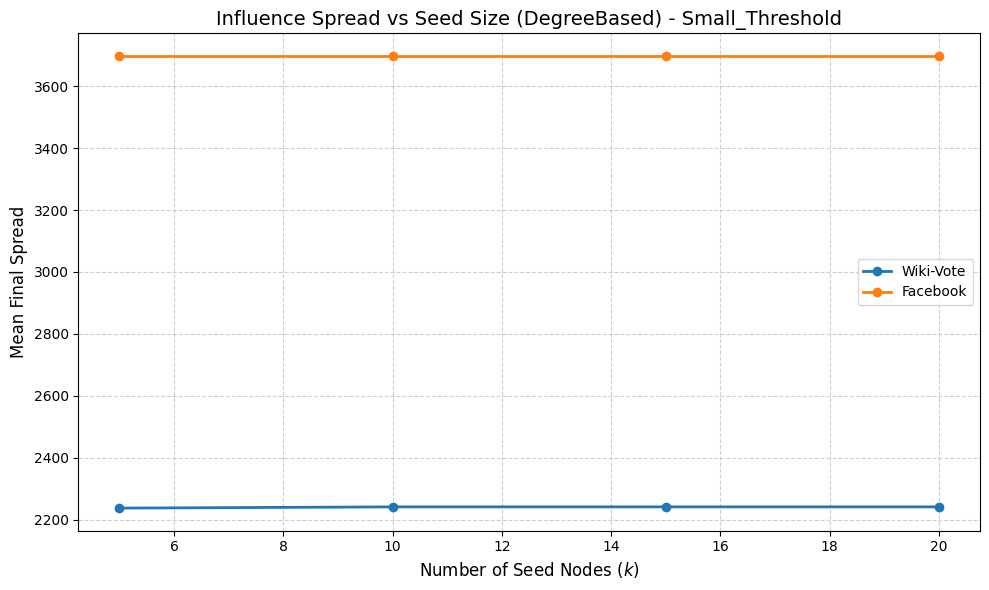

In [ ]:
size_results = analyze_seed_sizes_across_graphs(
    Graph_dict,
    Small_Threshold,
    seed_strategy="DegreeBased",
    seed_sizes=[5, 10, 15, 20],
    runs = 5,
    param_generator=st_params
)

*Majority Threshold Model*

In [8]:
class Majority_Threshold:
    def __init__(self, G, A0):
        self.graph = G
        self.active_nodes = set(A0)
        self.newly_active = list(A0)
        self.history = [set(A0)]
        self.thresholds = {node: self.graph.degree(node) / 2 for node in G.nodes()}
        self.active_neighbor_count = {node: 0 for node in G.nodes()}


    def run(self):
        while self.newly_active:
            next_newly_active = []
            candidates = set()

            for u in self.newly_active:
                for v in self.graph.neighbors(u):
                    if v not in self.active_nodes:
                        self.active_neighbor_count[v] += 1
                        candidates.add(v)

            for v in candidates:
                if self.active_neighbor_count[v] >= self.thresholds[v]:
                    next_newly_active.append(v)
                    self.active_nodes.add(v)

            if not next_newly_active:
                break

            self.history.append(set(next_newly_active))
            self.newly_active = next_newly_active

        return self.active_nodes, self.history

In [9]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()

#Param Function
def mt_params(graph):
    return {}
results_wiki2 = Experiment(G1, Majority_Threshold, seeds1, runs=10, param_func=mt_params).run()
results_fb2 = Experiment(G2, Majority_Threshold, seeds2, runs=10, param_func=mt_params).run()

all_results2 = {
    "Wiki-Vote": results_wiki2,
    "Facebook": results_fb2,
}

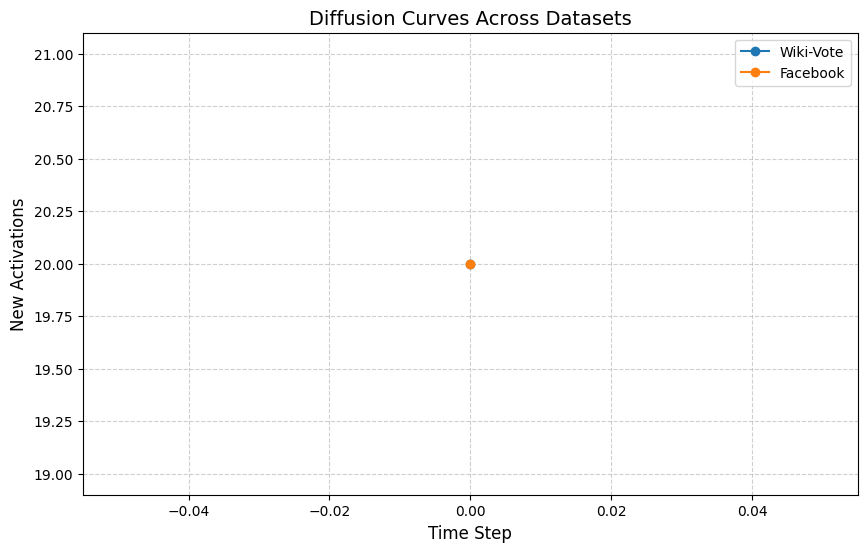

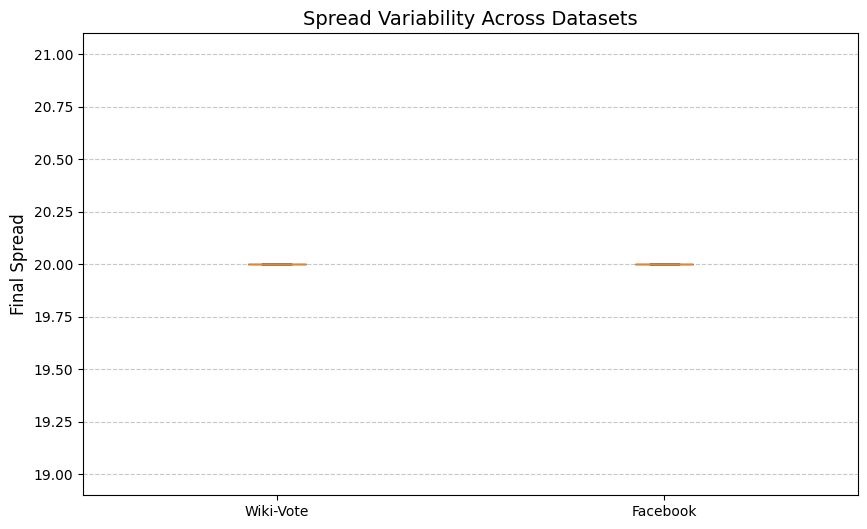

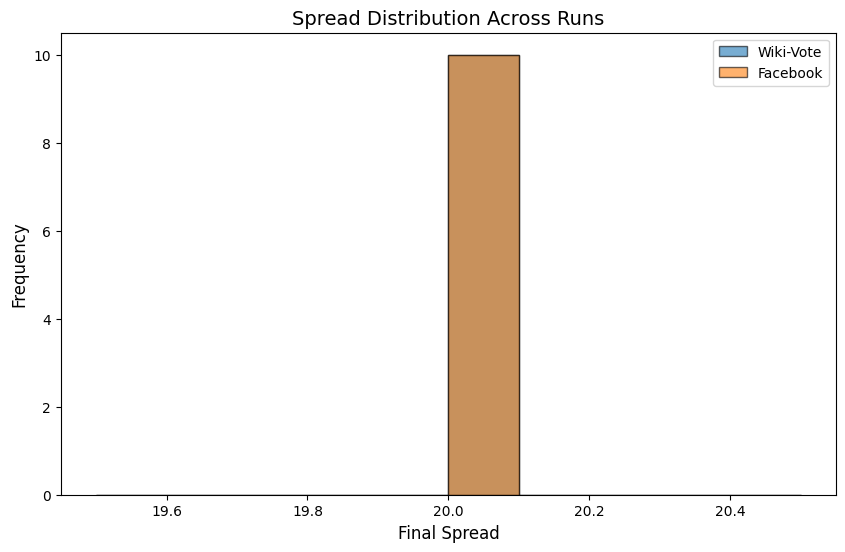

In [10]:
plot_diffusion_curves(all_results2)
plot_variances(all_results2)
plot_spread_distributions(all_results2)

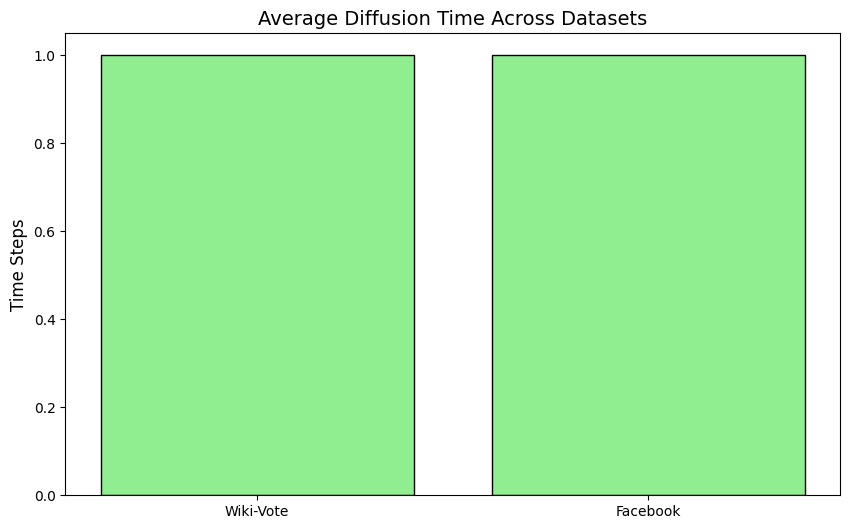

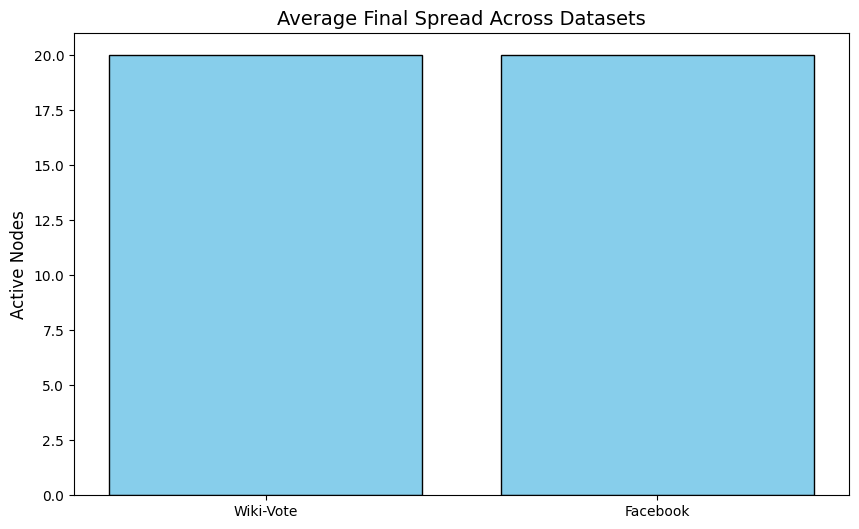

In [11]:
plot_diffusion_times(all_results2)
plot_final_spreads(all_results2)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


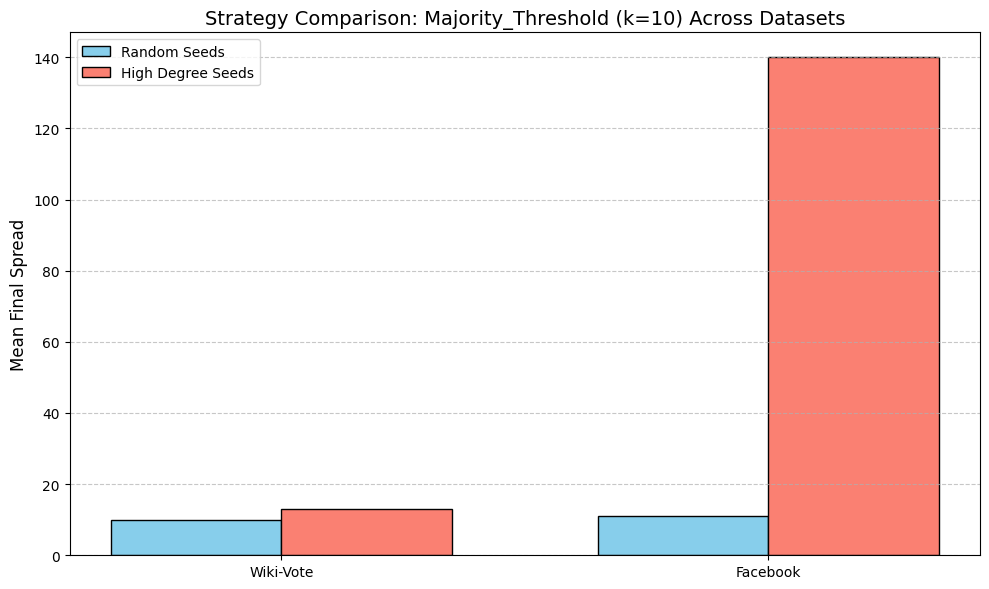

In [12]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
strategy_results = compare_seed_strategies_across_graphs(Graph_dict, Majority_Threshold, k=10, runs = 5,
    param_generator=mt_params)


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 6.00
  k=10 | Mean Spread: 13.00
  k=15 | Mean Spread: 18.00
  k=20 | Mean Spread: 26.00

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 135.00
  k=10 | Mean Spread: 140.00
  k=15 | Mean Spread: 157.00
  k=20 | Mean Spread: 162.00


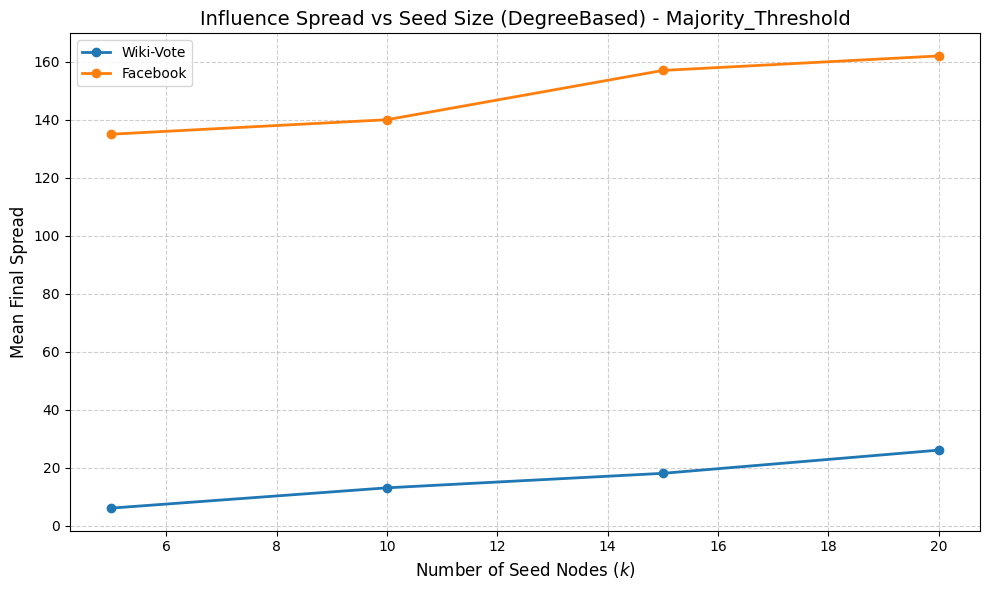

In [13]:
size_results = analyze_seed_sizes_across_graphs(
    Graph_dict,
    Majority_Threshold,
    seed_strategy="DegreeBased",
    seed_sizes=[5, 10, 15, 20],
    runs = 5,
    param_generator=mt_params
)

*Unanimous Threshold*

In [14]:
class Unanimous_Threshold:
    def __init__(self, G, A0):
        self.graph = G
        self.active_nodes = set(A0)
        self.newly_active = list(A0)
        self.history = [set(A0)]
        self.thresholds = {node: self.graph.degree(node) for node in G.nodes()}
        self.active_neighbor_count = {node: 0 for node in G.nodes()}


    def run(self):
        while self.newly_active:
            next_newly_active = []
            candidates = set()

            for u in self.newly_active:
                for v in self.graph.neighbors(u):
                    if v not in self.active_nodes:
                        self.active_neighbor_count[v] += 1
                        candidates.add(v)

            for v in candidates:
                if self.active_neighbor_count[v] >= self.thresholds[v]:
                    next_newly_active.append(v)
                    self.active_nodes.add(v)

            if not next_newly_active:
                break

            self.history.append(set(next_newly_active))
            self.newly_active = next_newly_active

        return self.active_nodes, self.history

In [15]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()

#Param Function
def ut_params(graph):
    return {}
results_wiki3 = Experiment(G1, Unanimous_Threshold, seeds1, runs=10, param_func=ut_params).run()
results_fb3 = Experiment(G2, Unanimous_Threshold, seeds2, runs=10, param_func=ut_params).run()

all_results3 = {
    "Wiki-Vote": results_wiki3,
    "Facebook": results_fb3,
}

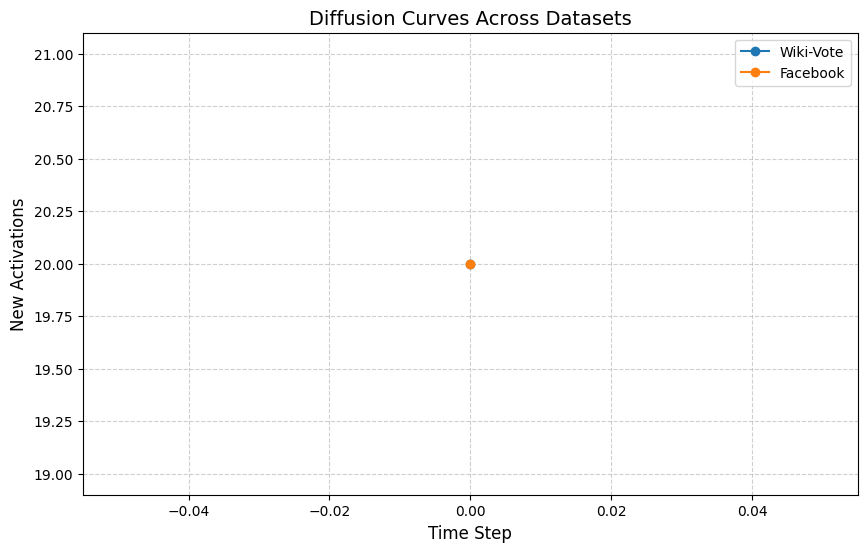

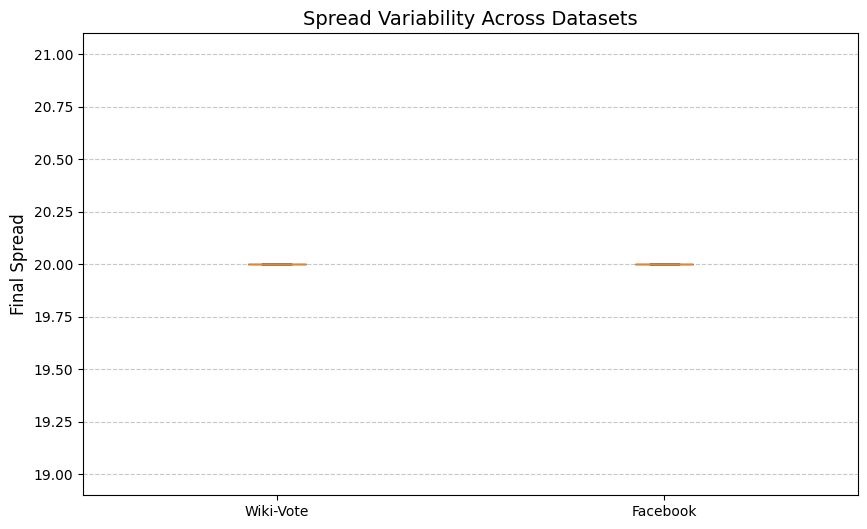

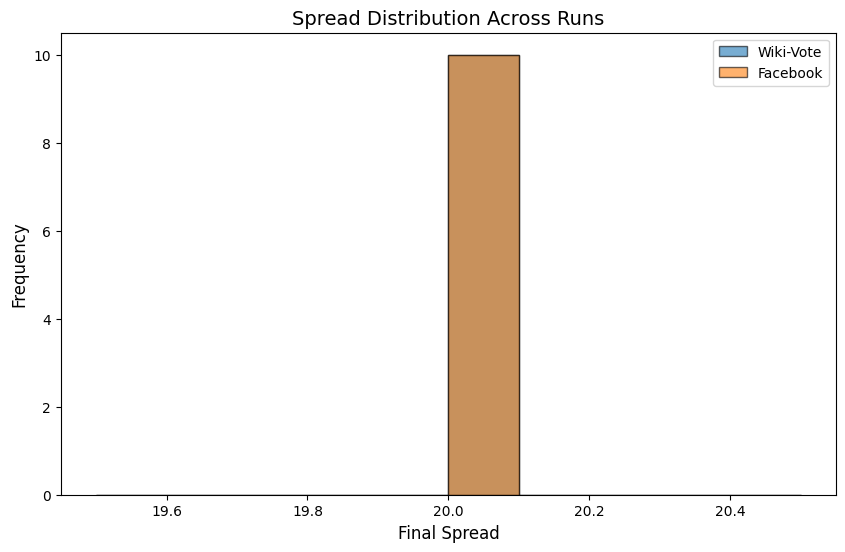

In [16]:
plot_diffusion_curves(all_results3)
plot_variances(all_results3)
plot_spread_distributions(all_results3)

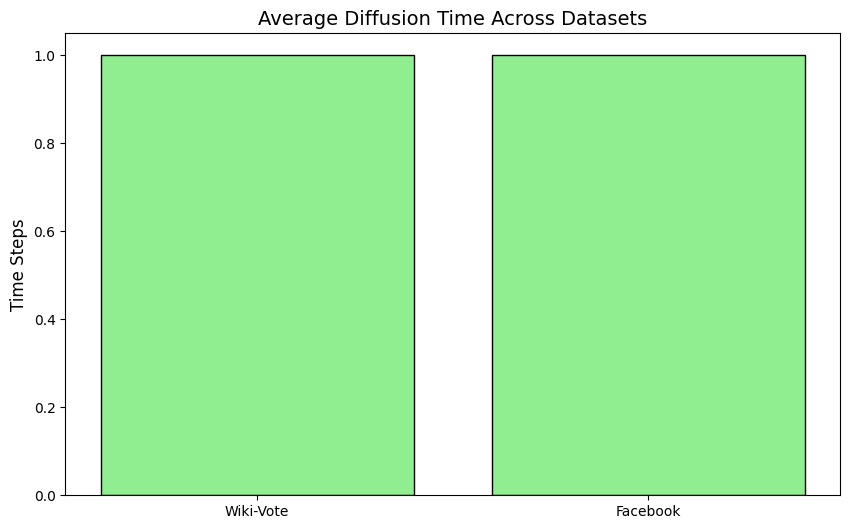

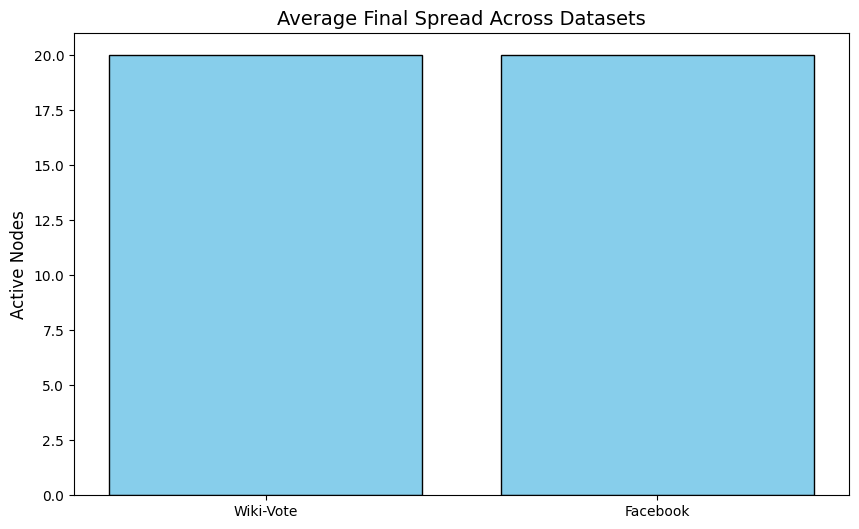

In [19]:
plot_diffusion_times(all_results3)
plot_final_spreads(all_results3)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


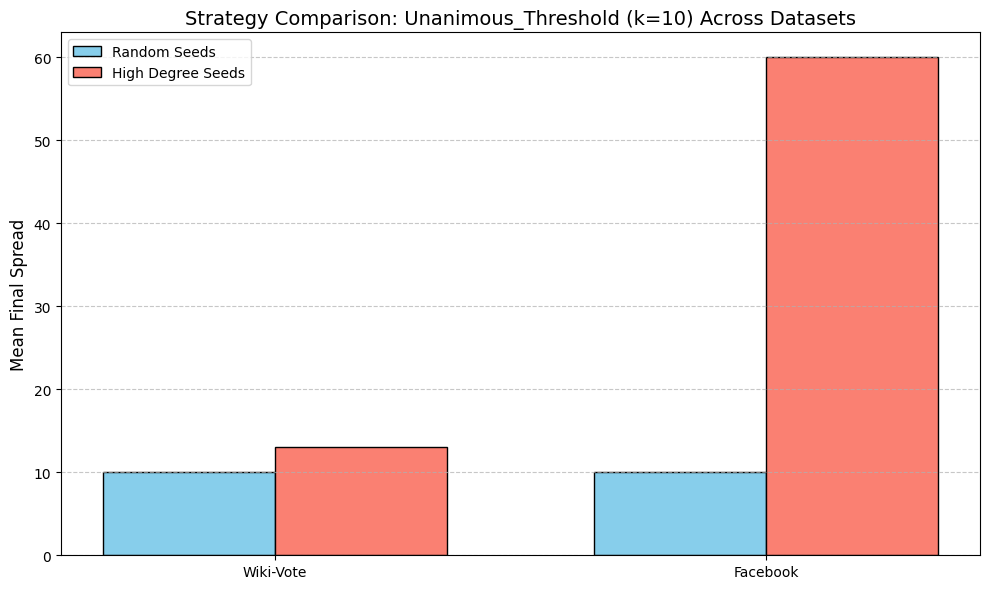

In [17]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
strategy_results = compare_seed_strategies_across_graphs(Graph_dict, Unanimous_Threshold, k=10, runs = 5,
    param_generator=ut_params)


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 6.00
  k=10 | Mean Spread: 13.00
  k=15 | Mean Spread: 18.00
  k=20 | Mean Spread: 24.00

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 55.00
  k=10 | Mean Spread: 60.00
  k=15 | Mean Spread: 68.00
  k=20 | Mean Spread: 73.00


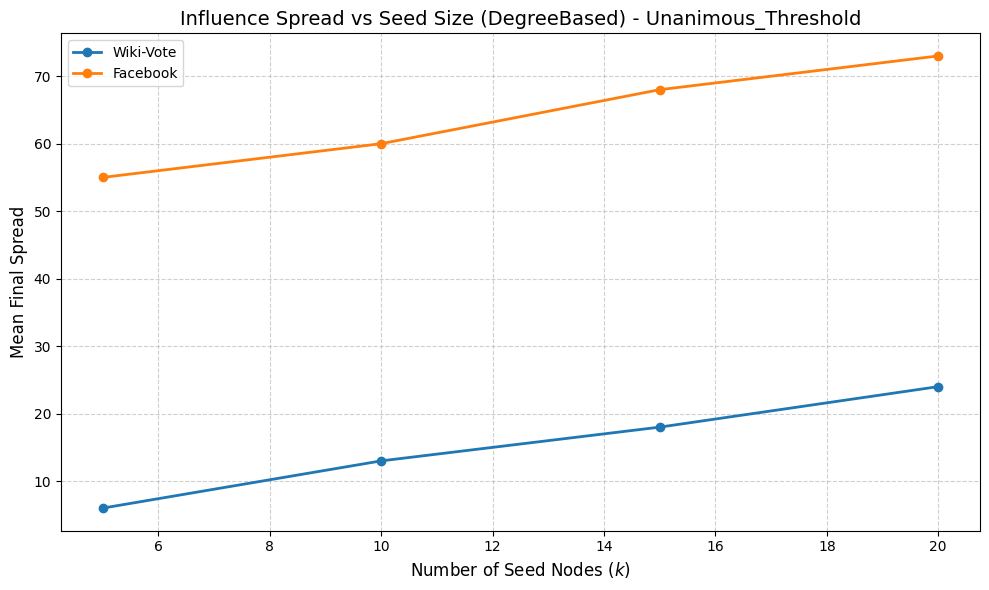

In [18]:
size_results = analyze_seed_sizes_across_graphs(
    Graph_dict,
    Unanimous_Threshold,
    seed_strategy="DegreeBased",
    seed_sizes=[5, 10, 15, 20],
    runs = 5,
    param_generator=ut_params
)